In [1]:
# get data from all_particle_data
import numpy as np
import matplotlib.pyplot as plt
n_snapshots = 100+1
npts = 650000

dt = np.dtype([('rank','i4'),('R','f4'),('Vrad','f4'),('L','f4'),('species','i4')])
data = np.fromfile("/home/posner/NSphere/data/all_particle_data_650000_10001_0.1.dat",dtype = dt).reshape(n_snapshots, npts)

rad = data["R"]
species = data["species"]
Vrad = data["Vrad"]

print(data.shape)

(101, 650000)


In [2]:
# get time array

def get_timestamps(tag = "", suffix = "100000_10001_5"):
    "Reads the single_trajectory files from the data directory and constructs a data array from them"

    #create path path
    if tag == "":
        file_path = "../data/single_trajectory" + "_" + suffix + ".dat"
    else:
        file_path = "../data/single_trajectory" + "_" + tag + "_" + suffix + ".dat"

    #define data types
    record_dtype = np.dtype([
        ('time',  np.float32),
        ('R',     np.float32),
        ('Vrad',  np.float32),
        ('mu',  np.float32),
    ])
    
    #read the files and build data array
    try:
        # Read the binary file and extract radius data
        alldata = np.fromfile(file_path, dtype=record_dtype)
        data = alldata['R']

        if np.isnan(data).any():
            print(f"Warning: NaN values found in data at Time Step: {time_step}")
        if not np.isfinite(data).all():
            print(f"Warning: Infinite values found in data at Time Step: {time_step}")

    except Exception as e:
        print(f"Error reading file {file_path}: {e}")
    return alldata["time"]

physical_time = get_timestamps(suffix = "650000_10001_0.1")
time_total = physical_time[-1] - physical_time[0]
delta_t = time_total / n_snapshots

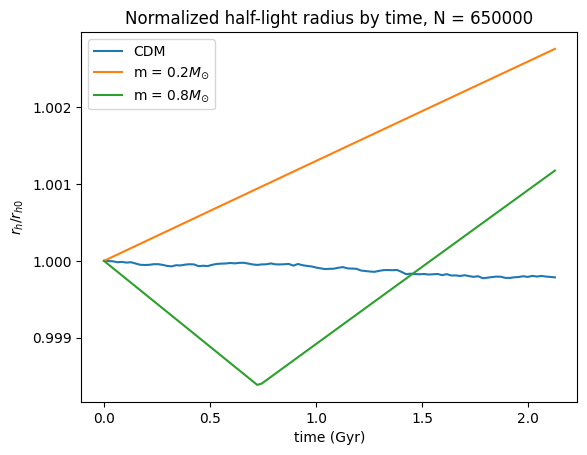

In [3]:
import matplotlib.pyplot as plt

def calculate_halflight_radius(r):
    if np.isnan(r).sum():
        raise("r contains NaN values.")

    r_sorted = np.sort(r)
    return r_sorted[len(r_sorted)//2]

time = (delta_t/1000) * range(n_snapshots)

species_to_graph = [0,1,2] # add or remove species later
species_titles = [r"CDM",r"m = 0.2$M_{\odot}$",r"m = 0.8$M_{\odot}$"]

for s,label in zip(species_to_graph,species_titles):
    r_halflight = []
    for i in range(rad.shape[0]):
        mask = (species[i] == s)
        r_halflight.append(calculate_halflight_radius(rad[i][mask]))
    r_halflight = np.array(r_halflight)
    r_halflight_norm = r_halflight/r_halflight[0]
    
    plt.plot(time,r_halflight_norm, label = label)

plt.title("Normalized half-light radius by time, N = 650000")
plt.ylabel(r"$r_h$/$r_{h0}$")
plt.xlabel(r"time (Gyr)")
plt.legend();

#plt.savefig('../results/dynamical_friction_energy_lost.png', dpi=300, bbox_inches='tight')


